In [3]:
# unzip file
from zipfile import ZipFile

fileName = 'archive'

with ZipFile("demo_data/"+fileName+".zip", 'r') as zObject:
    zObject.extractall(
      path="demo_data/")

In [12]:
#!conda install opencv -y

In [1]:
import os
import cv2
import numpy as np

from matplotlib import pyplot as plt
from patchify import patchify
from PIL import Image
#import segmentation_models as sm
from tensorflow.keras.metrics import MeanIoU

from sklearn.preprocessing import MinMaxScaler, StandardScaler

os.environ["SM_FRAMEWORK"] = "tf.keras"

from tensorflow import keras
import segmentation_models as sm

"""
Use patchify....
Tile 1: 797 x 644 --> 768 x 512 --> 6
Tile 2: 509 x 544 --> 512 x 256 --> 2
Tile 3: 682 x 658 --> 512 x 512  --> 4
Tile 4: 1099 x 846 --> 1024 x 768 --> 12
Tile 5: 1126 x 1058 --> 1024 x 1024 --> 16
Tile 6: 859 x 838 --> 768 x 768 --> 9
Tile 7: 1817 x 2061 --> 1792 x 2048 --> 56
Tile 8: 2149 x 1479 --> 1280 x 2048 --> 40
Total 9 images in each folder * (145 patches) = 1305
Total 1305 patches of size 256x256
"""


scaler = MinMaxScaler()

#root_directory = 'demo_data/Semantic segmentation dataset/'
#root_directory = 'satData/S2B_MSIL2A_20230612T073619_N0509_R092_T37NCC_20230612T101141\.SAFE/GRANULE/L2A_T37NCC_A032722_20230612T075442/IMG_DATA/R10m/'
#root_directory = 'bands'

patch_size = 256

2023-07-03 14:04:10.155084: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-07-03 14:04:11.160087: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-07-03 14:04:11.163277: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-07-03 14:04:13.217644: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Segmentation Models: using `tf.keras` framework.


In [2]:
root_directory = 'sat_Data/S2A_MSIL2A_20230627T073621_N0509_R092_T37NCC_20230627T110801.SAFE/GRANULE/L2A_T37NCC_A041845_20230627T075440/IMG_DATA/'
root_directory

'sat_Data/S2A_MSIL2A_20230627T073621_N0509_R092_T37NCC_20230627T110801.SAFE/GRANULE/L2A_T37NCC_A041845_20230627T075440/IMG_DATA/'

In [3]:
#Read images from repsective 'images' subdirectory
#As all images are of ddifferent size we have 2 options, either resize or crop
#But, some images are too large and some small. Resizing will change the size of real objects.
#Therefore, we will crop them to a nearest size divisible by 256 and then 
#divide all images into patches of 256x256x3. 
image_dataset = []  
for path, subdirs, files in os.walk(root_directory):
    print(path)  
    dirname = path.split(os.path.sep)[-1]
    if dirname == 'test':   #Find all 'images' directories
        images = os.listdir(path)  #List of all image names in this subdirectory
        for i, image_name in enumerate(images):  
            if image_name.endswith(".jp2"):   #Only read jpg images...
               
                image = cv2.imread(path+"/"+image_name, 1)  #Read each image as BGR
                SIZE_X = (image.shape[1]//patch_size)*patch_size #Nearest size divisible by our patch size
                SIZE_Y = (image.shape[0]//patch_size)*patch_size #Nearest size divisible by our patch size
                image = Image.fromarray(image)
                image = image.crop((0 ,0, SIZE_X, SIZE_Y))  #Crop from top left corner
                #image = image.resize((SIZE_X, SIZE_Y))  #Try not to resize for semantic segmentation
                image = np.array(image)             
       
                #Extract patches from each image
                print("Now patchifying image:", path+"/"+image_name)
                patches_img = patchify(image, (patch_size, patch_size, 3), step=patch_size)  #Step=256 for 256 patches means no overlap
        
                for i in range(patches_img.shape[0]):
                    for j in range(patches_img.shape[1]):
                        
                        single_patch_img = patches_img[i,j,:,:]
                        
                        #Use minmaxscaler instead of just dividing by 255. 
                        single_patch_img = scaler.fit_transform(single_patch_img.reshape(-1, single_patch_img.shape[-1])).reshape(single_patch_img.shape)
                        
                        #single_patch_img = (single_patch_img.astype('float32')) / 255. 
                        single_patch_img = single_patch_img[0] #Drop the extra unecessary dimension that patchify adds.                               
                        image_dataset.append(single_patch_img)
                

sat_Data/S2A_MSIL2A_20230627T073621_N0509_R092_T37NCC_20230627T110801.SAFE/GRANULE/L2A_T37NCC_A041845_20230627T075440/IMG_DATA/
sat_Data/S2A_MSIL2A_20230627T073621_N0509_R092_T37NCC_20230627T110801.SAFE/GRANULE/L2A_T37NCC_A041845_20230627T075440/IMG_DATA/R10m
sat_Data/S2A_MSIL2A_20230627T073621_N0509_R092_T37NCC_20230627T110801.SAFE/GRANULE/L2A_T37NCC_A041845_20230627T075440/IMG_DATA/R20m
sat_Data/S2A_MSIL2A_20230627T073621_N0509_R092_T37NCC_20230627T110801.SAFE/GRANULE/L2A_T37NCC_A041845_20230627T075440/IMG_DATA/test


/opt/conda/lib/python3.11/site-packages/PIL/Image.py:3176: DecompressionBombWarning: Image size (115605504 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Now patchifying image: sat_Data/S2A_MSIL2A_20230627T073621_N0509_R092_T37NCC_20230627T110801.SAFE/GRANULE/L2A_T37NCC_A041845_20230627T075440/IMG_DATA/test/T37NCC_20230627T073621_TCI_10m.jp2
sat_Data/S2A_MSIL2A_20230627T073621_N0509_R092_T37NCC_20230627T110801.SAFE/GRANULE/L2A_T37NCC_A041845_20230627T075440/IMG_DATA/.ipynb_checkpoints
sat_Data/S2A_MSIL2A_20230627T073621_N0509_R092_T37NCC_20230627T110801.SAFE/GRANULE/L2A_T37NCC_A041845_20230627T075440/IMG_DATA/R60m


In [4]:
#image_dataset

In [5]:
#Now do the same as above for masks
#For this specific dataset we could have added masks to the above code as masks have extension png
mask_dataset = []  
for path, subdirs, files in os.walk('/home/jovyan'):
    #print(path)  
    dirname = path.split(os.path.sep)[-1]
    if dirname == '_results':   #Find all 'images' directories
        masks = os.listdir(path)  #List of all image names in this subdirectory
        for i, mask_name in enumerate(masks):  
            if mask_name.endswith(".png"):   #Only read png images... (masks in this dataset)
               
                mask = cv2.imread(path+"/"+mask_name, 1)  #Read each image as Grey (or color but remember to map each color to an integer)
                mask = cv2.cvtColor(mask,cv2.COLOR_BGR2RGB)
                SIZE_X = (mask.shape[1]//patch_size)*patch_size #Nearest size divisible by our patch size
                SIZE_Y = (mask.shape[0]//patch_size)*patch_size #Nearest size divisible by our patch size
                mask = Image.fromarray(mask)
                mask = mask.crop((0 ,0, SIZE_X, SIZE_Y))  #Crop from top left corner
                #mask = mask.resize((SIZE_X, SIZE_Y))  #Try not to resize for semantic segmentation
                mask = np.array(mask)             
       
                #Extract patches from each image
                print("Now patchifying mask:", path+"/"+mask_name)
                patches_mask = patchify(mask, (patch_size, patch_size, 3), step=patch_size)  #Step=256 for 256 patches means no overlap
        
                for i in range(patches_mask.shape[0]):
                    for j in range(patches_mask.shape[1]):
                        
                        single_patch_mask = patches_mask[i,j,:,:]
                        #single_patch_img = (single_patch_img.astype('float32')) / 255. #No need to scale masks, but you can do it if you want
                        single_patch_mask = single_patch_mask[0] #Drop the extra unecessary dimension that patchify adds.                               
                        mask_dataset.append(single_patch_mask) 
 

/opt/conda/lib/python3.11/site-packages/PIL/Image.py:3176: DecompressionBombWarning: Image size (115605504 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Now patchifying mask: /home/jovyan/_results/20230627_unsupervised99_rgb.png


In [6]:
image_dataset = np.array(image_dataset)


In [7]:
mask_dataset =  np.array(mask_dataset)


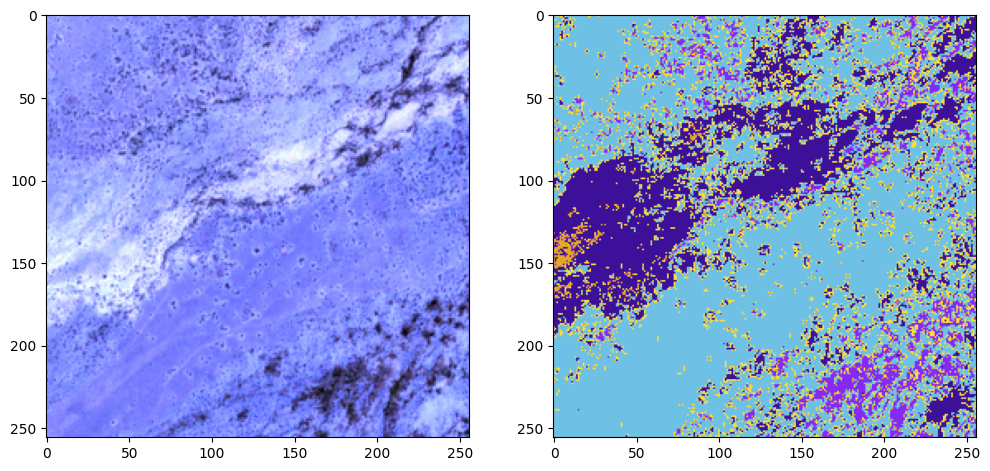

In [8]:
#Sanity check, view few mages
import random
import numpy as np
image_number = random.randint(0, len(image_dataset))
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(np.reshape(image_dataset[image_number], (patch_size, patch_size, 3)))
plt.subplot(122)
plt.imshow(np.reshape(mask_dataset[image_number], (patch_size, patch_size, 3)))
plt.show()

In [9]:
"""
RGB to HEX: (Hexadecimel --> base 16)
This number divided by sixteen (integer division; ignoring any remainder) gives 
the first hexadecimal digit (between 0 and F, where the letters A to F represent 
the numbers 10 to 15). The remainder gives the second hexadecimal digit. 
0-9 --> 0-9
10-15 --> A-F
Example: RGB --> R=201, G=, B=
R = 201/16 = 12 with remainder of 9. So hex code for R is C9 (remember C=12)
Calculating RGB from HEX: #3C1098
3C = 3*16 + 12 = 60
10 = 1*16 + 0 = 16
98 = 9*16 + 8 = 152
"""
## Convert HEX to RGB array
## Try the following to understand how python handles hex values...

#a=int('3C', 16)  #3C with base 16. Should return 60. 
#print(a)

##Do the same for all RGB channels in each hex code to convert to RGB
#Building = '#3C1098'.lstrip('#')
#Building = np.array(tuple(int(Building[i:i+2], 16) for i in (0, 2, 4))) # 60, 16, 152
Building=np.array((60, 16, 152))
#Land = '#8429F6'.lstrip('#')
#Land = np.array(tuple(int(Land[i:i+2], 16) for i in (0, 2, 4))) #132, 41, 246
Land=np.array((5,5,5))
#Road = '#6EC1E4'.lstrip('#') 
#Road = np.array(tuple(int(Road[i:i+2], 16) for i in (0, 2, 4))) #110, 193, 228
Road=np.array((110, 193, 228))
#Vegetation =  'FEDD3A'.lstrip('#') 
#Vegetation = np.array(tuple(int(Vegetation[i:i+2], 16) for i in (0, 2, 4))) #254, 221, 58
Vegetation=np.array((254, 221, 58))
#Water = 'E2A929'.lstrip('#') 
#Water = np.array(tuple(int(Water[i:i+2], 16) for i in (0, 2, 4))) #226, 169, 41
Water=np.array((226, 169, 41))
#Unlabeled = '#9B9B9B'.lstrip('#') 
#Unlabeled = np.array(tuple(int(Unlabeled[i:i+2], 16) for i in (0, 2, 4))) #155, 155, 155
Unlabeled=np.array((155, 155, 155))

In [10]:
label = single_patch_mask

# Now replace RGB to integer values to be used as labels.
#Find pixels with combination of RGB for the above defined arrays...
#if matches then replace all values in that pixel with a specific integer
def rgb_to_2D_label(label):
    """
    Suply our labale masks as input in RGB format. 
    Replace pixels with specific RGB values ...
    """
    label_seg = np.zeros(label.shape,dtype=np.uint8)
    label_seg [np.all(label==Building,axis=-1)] = 0
    label_seg [np.all(label==Land,axis=-1)] = 1
    label_seg [np.all(label==Road,axis=-1)] = 2
    label_seg [np.all(label==Vegetation,axis=-1)] = 3
    label_seg [np.all(label==Water,axis=-1)] = 4
    label_seg [np.all(label==Unlabeled,axis=-1)] = 5
    
    label_seg = label_seg[:,:,0]  #Just take the first channel, no need for all 3 channels
    
    return label_seg

labels = []
for i in range(mask_dataset.shape[0]):
    label = rgb_to_2D_label(mask_dataset[i])
    labels.append(label)    

labels = np.array(labels)   
labels = np.expand_dims(labels, axis=3)
 

print("Unique labels in label dataset are: ", np.unique(labels))

Unique labels in label dataset are:  [0 2 3 4 5]


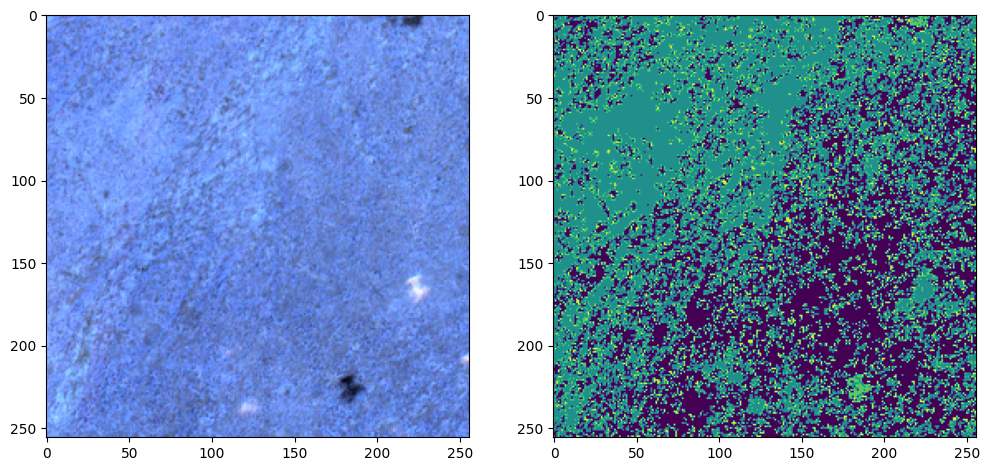

In [11]:
#Another Sanity check, view few mages
import random
import numpy as np
image_number = random.randint(0, len(image_dataset))
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(image_dataset[image_number])
plt.subplot(122)
plt.imshow(labels[image_number][:,:,0])
plt.show()

In [12]:

n_classes = len(np.unique(labels))
from keras.utils import to_categorical
#labels_cat = to_categorical(labels, num_classes=n_classes)
labels_cat = to_categorical(labels, num_classes=10)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(image_dataset, labels_cat, test_size = 0.20, random_state = 42)


In [13]:

weights = [0.1666, 0.1666, 0.1666, 0.1666, 0.1666, 0.1666, 0.1666, 0.1666, 0.1666, 0.1666]
dice_loss = sm.losses.DiceLoss(class_weights=weights) 
focal_loss = sm.losses.CategoricalFocalLoss()
total_loss = dice_loss + (1 * focal_loss)  #


IMG_HEIGHT = X_train.shape[1]
IMG_WIDTH  = X_train.shape[2]
IMG_CHANNELS = X_train.shape[3]

from simple_multi_unet_model import multi_unet_model, jacard_coef  

metrics=['accuracy', jacard_coef]

def get_model():
    return multi_unet_model(n_classes=n_classes, IMG_HEIGHT=IMG_HEIGHT, IMG_WIDTH=IMG_WIDTH, IMG_CHANNELS=IMG_CHANNELS)

model = get_model()
model.compile(optimizer='adam', loss=total_loss, metrics=metrics)
#model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=metrics)
model.summary()


history1 = model.fit(X_train, y_train, 
                    batch_size = 16, 
                    verbose=1, 
                    epochs=100, 
                    validation_data=(X_test, y_test), 
                    shuffle=False)


ModuleNotFoundError: No module named 'simple_multi_unet_model'